# Benchmark Comparison: SGLang Disaggregated TP1 (4P4D) vs. TP2 (2P2D)

Clean white-background charts for **Concurrency 128** and **Concurrency Scaling Sweep (c1 to c128)** with high-contrast, balanced bar colors (`#475569` Slate Gray for TP1-4P4D vs `#ea580c` Vibrant Orange for TP2-2P2D), descriptive units, top-aligned titles, 2-item legend, and clear winner indicators.

In [17]:
%matplotlib inline
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Robust Path Resolver for AIPerf JSON exports
def resolve_json_path(rel_subpath: str) -> Path:
    abs_base = Path("/data/inference/cluster/models/qwen3.6-35B-A3B/artifacts")
    candidate = abs_base / rel_subpath
    if candidate.exists():
        return candidate
    cwd = Path(os.getcwd())
    for p in [cwd] + list(cwd.parents):
        cand = p / "artifacts" / rel_subpath
        if cand.exists():
            return cand
    return candidate

BASELINE_JSON = resolve_json_path("tp1-4p4d/benchmarks/c128/profile_export_aiperf.json")
OFFLOAD_JSON = resolve_json_path("tp2-2p2d/benchmarks/c128/profile_export_aiperf.json")
TP1_BENCH_DIR = resolve_json_path("tp1-4p4d/benchmarks")
TP2_BENCH_DIR = resolve_json_path("tp2-2p2d/benchmarks")
CONCURRENCIES = [1, 4, 8, 16, 32, 64, 128]

# High-Contrast Professional Palette (Clean White Theme with Slate & Orange)
BG_COLOR = "#ffffff"       # Pure white background
CARD_BG = "#ffffff"        # Pure white plot area
GRID_COLOR = "#e2e8f0"     # Subtle slate gridline
BORDER_COLOR = "#cbd5e1"   # Clean border
TEXT_MUTED = "#64748b"     # Muted slate for units/subheaders
TEXT_MAIN = "#1e293b"      # Dark slate for labels
TEXT_DARK = "#0f172a"      # Deep charcoal for titles and numbers
COLOR_BASELINE = "#475569" # Solid Slate Gray for TP1 (4P4D: 4 Prefill / 4 Decode TP1)
COLOR_OFFLOAD = "#ea580c"  # Vibrant Orange for TP2 (2P2D: 2 Prefill / 2 Decode TP2)
WINNER_BG = "#ecfdf5"      # Light emerald green badge background
WINNER_BORDER = "#a7f3d0"  # Light emerald green border
WINNER_TEXT = "#047857"    # Dark emerald green text

def load_metrics(json_path: Path) -> dict:
    if not json_path.exists():
        raise FileNotFoundError(f"Metrics file not found: {json_path}")
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return {
        "output_tokens_per_sec": data.get("output_token_throughput", {}).get("avg", 0.0),
        "request_throughput": data.get("request_throughput", {}).get("avg", 0.0),
        "total_token_throughput": data.get("total_token_throughput", {}).get("avg", 0.0),
        "ttft_p50_ms": data.get("time_to_first_token", {}).get("p50", 0.0),
        "ttft_p50_s": data.get("time_to_first_token", {}).get("p50", 0.0) / 1000.0,
        "ttft_p95_ms": data.get("time_to_first_token", {}).get("p95", 0.0),
        "ttft_p95_s": data.get("time_to_first_token", {}).get("p95", 0.0) / 1000.0,
        "ttft_p99_ms": data.get("time_to_first_token", {}).get("p99", 0.0),
        "ttft_p99_s": data.get("time_to_first_token", {}).get("p99", 0.0) / 1000.0,
        "tpot_p99_ms": data.get("time_to_second_token", {}).get("p99", data.get("inter_token_latency", {}).get("p99", 0.0)),
        "itl_p50_ms": data.get("inter_token_latency", {}).get("p50", 0.0),
        "itl_p95_ms": data.get("inter_token_latency", {}).get("p95", 0.0),
        "itl_p99_ms": data.get("inter_token_latency", {}).get("p99", 0.0),
        "e2e_p50_ms": data.get("request_latency", {}).get("p50", 0.0),
        "e2e_p50_s": data.get("request_latency", {}).get("p50", 0.0) / 1000.0,
        "e2e_p95_ms": data.get("request_latency", {}).get("p95", 0.0),
        "e2e_p95_s": data.get("request_latency", {}).get("p95", 0.0) / 1000.0,
        "e2e_p99_ms": data.get("request_latency", {}).get("p99", 0.0),
        "e2e_p99_s": data.get("request_latency", {}).get("p99", 0.0) / 1000.0,
        "cache_hit_pct": data.get("overall_usage_prompt_cache_read_pct", {}).get("avg", 0.0),
    }

def load_all_concurrencies(base_dir: Path):
    results = {}
    for c in CONCURRENCIES:
        p = base_dir / f"c{c}" / "profile_export_aiperf.json"
        if p.exists():
            results[c] = load_metrics(p)
    return results

base = load_metrics(BASELINE_JSON)
offload = load_metrics(OFFLOAD_JSON)
tp1_all = load_all_concurrencies(TP1_BENCH_DIR)
tp2_all = load_all_concurrencies(TP2_BENCH_DIR)

def draw_single_card(
    ax,
    title: str,
    val_baseline: float,
    val_offload: float,
    unit: str,
    y_axis_label: str = None,
    higher_is_better: bool = True,
    y_max: float = None,
    format_str: str = "{:.2f}",
    detail_unit: str = None,
    val_baseline_detail: float = None,
    val_offload_detail: float = None,
    show_x_labels: bool = False,
):
    ax.set_facecolor(CARD_BG)
    x_positions = [0.75, 1.75]
    bar_width = 0.44

    # Determine Winner & Plain Text Direction
    if higher_is_better:
        base_wins = val_baseline > val_offload
        offload_wins = val_offload > val_baseline
        direction_text = "Higher is better"
    else:
        base_wins = val_baseline < val_offload
        offload_wins = val_offload < val_baseline
        direction_text = "Lower is better"

    ax.bar(
        x_positions,
        [val_baseline, val_offload],
        width=bar_width,
        color=[COLOR_BASELINE, COLOR_OFFLOAD],
        edgecolor=[COLOR_BASELINE, COLOR_OFFLOAD],
        linewidth=1.0,
        zorder=3,
    )

    max_val = max(val_baseline, val_offload)
    if y_max is None:
        y_max = max_val * 1.35 if max_val > 0 else 1.0

    ax.set_ylim(0, y_max)
    ax.set_xlim(0.1, 2.4)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7, color=GRID_COLOR, zorder=1)
    ax.xaxis.grid(False)

    # Title Placed Cleanly Above the Plot Area
    title_full = f"{title.upper()}  ({direction_text})"
    ax.set_title(
        title_full,
        loc="left",
        fontsize=9.5,
        fontweight="bold",
        color=TEXT_DARK,
        pad=10,
    )

    # Clearly Formatted Vertical Y-Axis Label
    label_text = y_axis_label if y_axis_label else f"({unit})"
    ax.set_ylabel(label_text, color=TEXT_MUTED, fontsize=9.0, labelpad=6)
    ax.tick_params(axis="y", colors=TEXT_MUTED, labelsize=8.5, length=0)
    ax.tick_params(axis="x", length=0, pad=6)

    # X-Axis Configuration
    if show_x_labels:
        ax.set_xticks(x_positions)
        ax.set_xticklabels(
            ["TP1 (4P4D)", "TP2 (2P2D)"],
            color=TEXT_MAIN, fontsize=9.0, fontweight="medium"
        )
    else:
        ax.set_xticks([])

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BORDER_COLOR)
    ax.spines["bottom"].set_linewidth(1.0)

    # Difference Calculation
    if higher_is_better:
        if base_wins and val_offload > 0:
            pct_diff = ((val_baseline - val_offload) / val_offload) * 100
            diff_label = f"+{pct_diff:.1f}%"
        elif offload_wins and val_baseline > 0:
            pct_diff = ((val_offload - val_baseline) / val_baseline) * 100
            diff_label = f"+{pct_diff:.1f}%"
        else:
            diff_label = ""
    else:
        if base_wins and val_offload > 0:
            reduction = ((val_offload - val_baseline) / val_offload) * 100
            diff_label = f"{reduction:.1f}% faster"
        elif offload_wins and val_baseline > 0:
            reduction = ((val_baseline - val_offload) / val_baseline) * 100
            diff_label = f"{reduction:.1f}% faster"
        else:
            diff_label = ""

    # Value strings with descriptive unit notation
    if val_baseline_detail is not None:
        base_text = f"{format_str.format(val_baseline)} {unit}\n({val_baseline_detail:,.0f} {detail_unit})"
    else:
        base_text = f"{format_str.format(val_baseline)} {unit}"

    if val_offload_detail is not None:
        offload_text = f"{format_str.format(val_offload)} {unit}\n({val_offload_detail:,.0f} {detail_unit})"
    else:
        offload_text = f"{format_str.format(val_offload)} {unit}"

    # Annotate Baseline Value
    ax.text(
        0.75, val_baseline + (y_max * 0.02), base_text,
        ha="center", va="bottom", color=TEXT_DARK if base_wins else TEXT_MUTED,
        fontsize=8.5, fontweight="bold" if base_wins else "normal", zorder=6
    )

    # Annotate Offload Value
    ax.text(
        1.75, val_offload + (y_max * 0.02), offload_text,
        ha="center", va="bottom", color=TEXT_DARK if offload_wins else TEXT_MUTED,
        fontsize=8.5, fontweight="bold" if offload_wins else "normal", zorder=6
    )

    # Highlight Winner Badge
    bbox_winner = dict(
        boxstyle="round,pad=0.4,rounding_size=0.3",
        facecolor=WINNER_BG, edgecolor=WINNER_BORDER, linewidth=1.0
    )
    if offload_wins:
        badge_y = val_offload + (y_max * 0.16 if val_offload_detail else y_max * 0.09)
        ax.text(
            1.75, badge_y, f"★ WINNER ({diff_label})",
            ha="center", va="bottom", color=WINNER_TEXT, fontsize=8.0,
            fontweight="bold", bbox=bbox_winner, zorder=7
        )
    elif base_wins:
        badge_y = val_baseline + (y_max * 0.16 if val_baseline_detail else y_max * 0.09)
        ax.text(
            0.75, badge_y, f"★ WINNER ({diff_label})",
            ha="center", va="bottom", color=WINNER_TEXT, fontsize=8.0,
            fontweight="bold", bbox=bbox_winner, zorder=7
        )

print("✓ Setup complete and benchmark metrics loaded!")

✓ Setup complete and benchmark metrics loaded!


### 1. Output Token Throughput (Standalone Card)

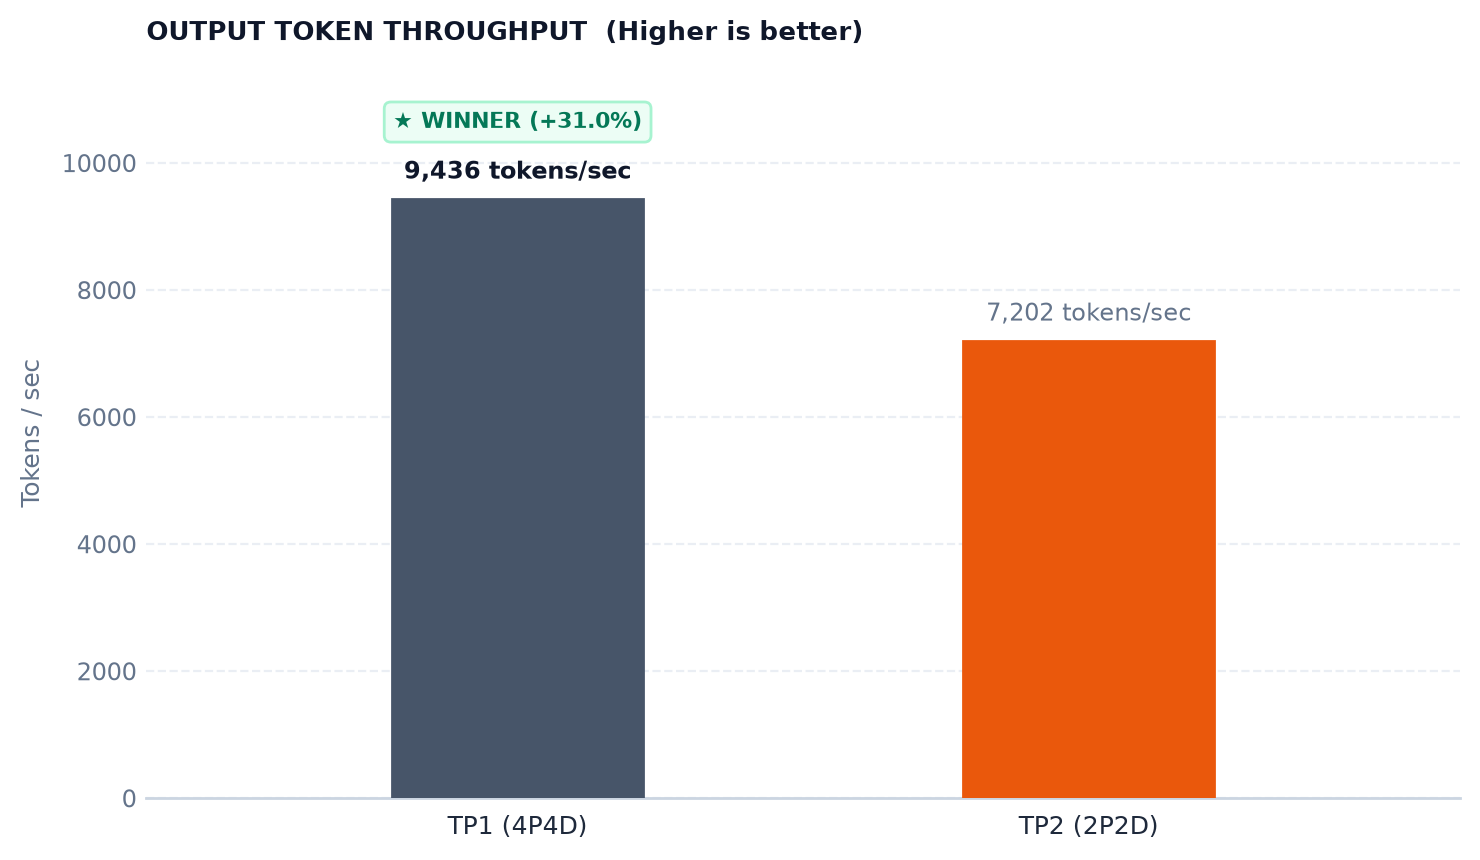

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor=BG_COLOR, dpi=200)
draw_single_card(
    ax=ax,
    title="Output Token Throughput",
    val_baseline=base["output_tokens_per_sec"],
    val_offload=offload["output_tokens_per_sec"],
    unit="tokens/sec",
    y_axis_label="Tokens / sec",
    higher_is_better=True,
    y_max=11500,
    format_str="{:,.0f}",
    show_x_labels=True,
)
plt.tight_layout()
plt.show()

### 2. Time to First Token (TTFT in seconds & milliseconds) — Lower is Better

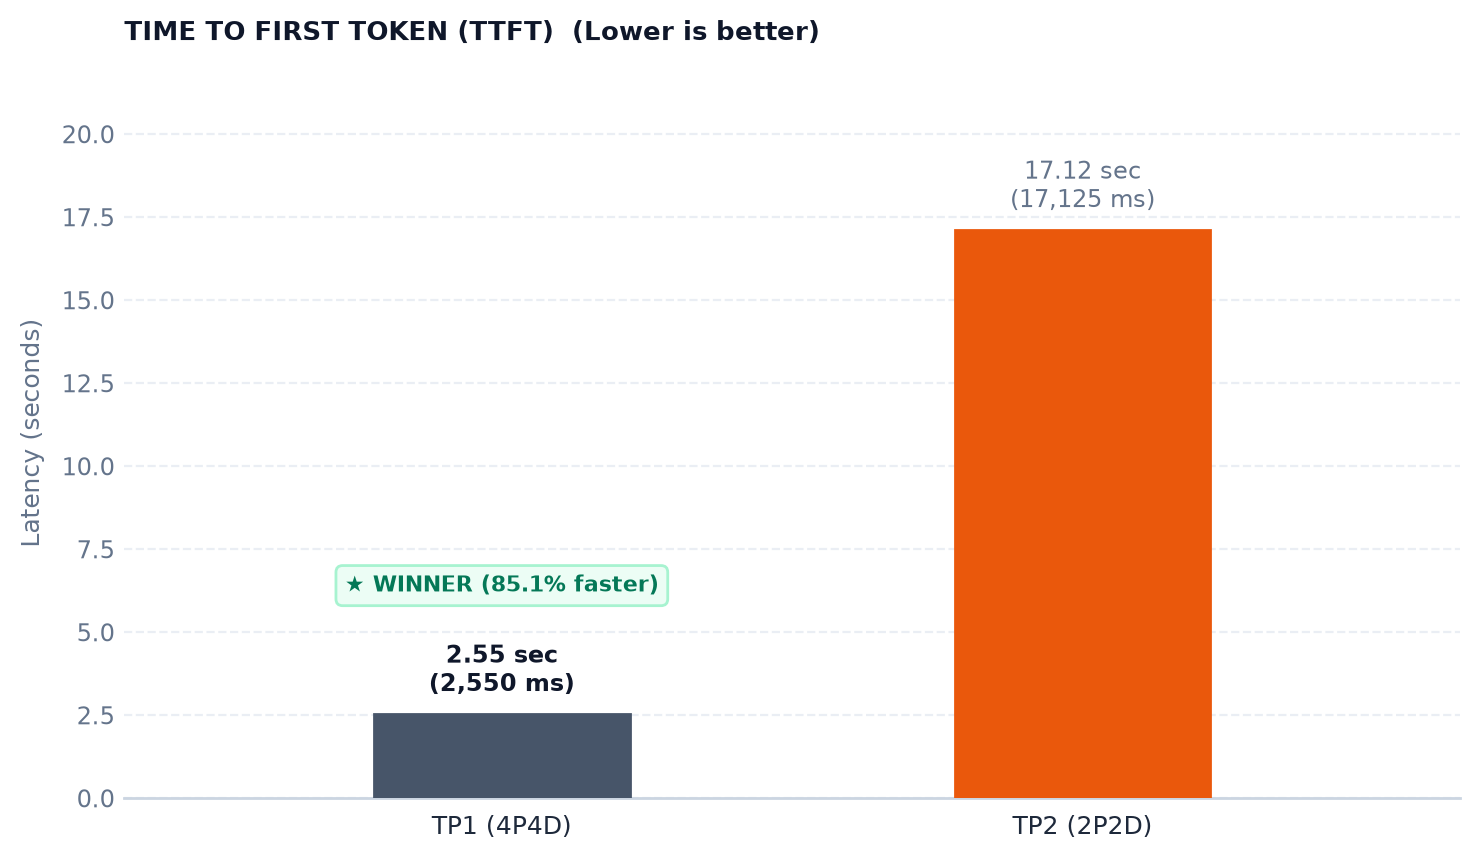

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor=BG_COLOR, dpi=200)
draw_single_card(
    ax=ax,
    title="Time to First Token (TTFT)",
    val_baseline=base["ttft_p99_s"],
    val_offload=offload["ttft_p99_s"],
    unit="sec",
    y_axis_label="Latency (seconds)",
    higher_is_better=False,
    y_max=22.0,
    format_str="{:.2f}",
    detail_unit="ms",
    val_baseline_detail=base["ttft_p99_ms"],
    val_offload_detail=offload["ttft_p99_ms"],
    show_x_labels=True,
)
plt.tight_layout()
plt.show()

### 3. Complete 6-Panel Benchmark Dashboard (C128) with Descriptive Units & Legend

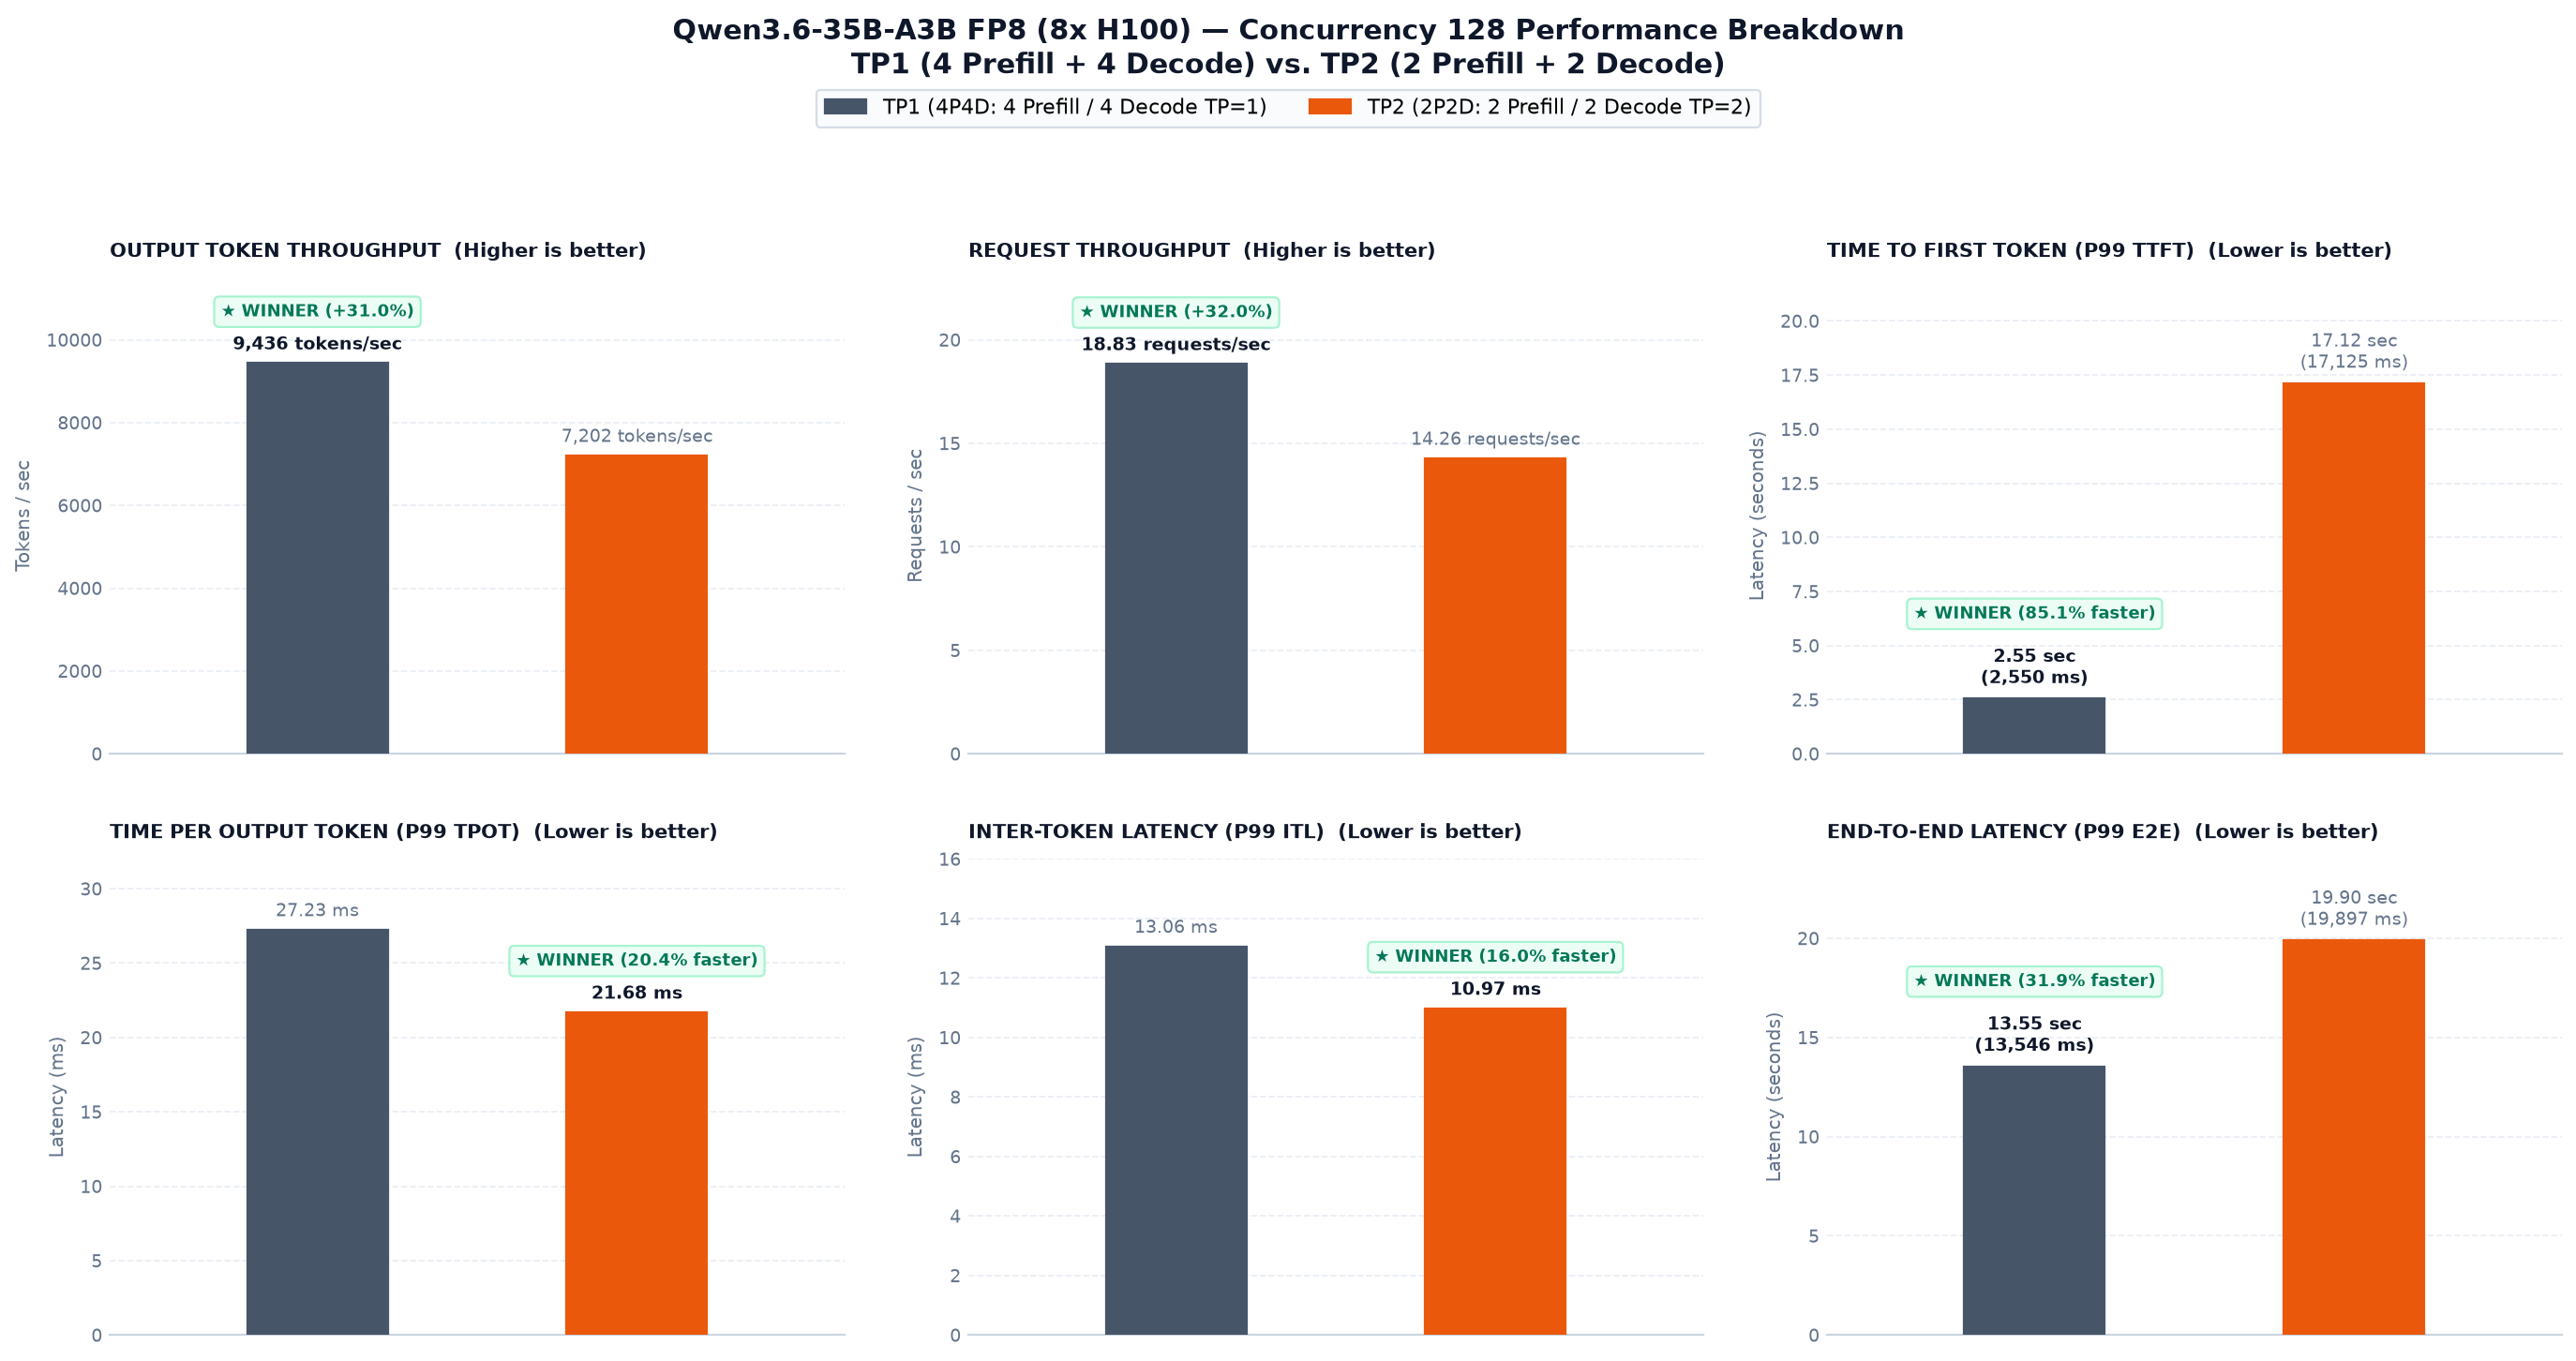

In [20]:
metrics_list = [
    {
        "title": "Output Token Throughput",
        "base": base["output_tokens_per_sec"],
        "off": offload["output_tokens_per_sec"],
        "unit": "tokens/sec",
        "y_label": "Tokens / sec",
        "higher_is_better": True,
        "ymax": 11500,
        "fmt": "{:,.0f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "Request Throughput",
        "base": base["request_throughput"],
        "off": offload["request_throughput"],
        "unit": "requests/sec",
        "y_label": "Requests / sec",
        "higher_is_better": True,
        "ymax": 23.0,
        "fmt": "{:.2f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "Time to First Token (P99 TTFT)",
        "base": base.get("ttft_p99_s", base.get("ttft_p99_ms", 0.0) / 1000.0),
        "off": offload.get("ttft_p99_s", offload.get("ttft_p99_ms", 0.0) / 1000.0),
        "unit": "sec",
        "y_label": "Latency (seconds)",
        "higher_is_better": False,
        "ymax": 22.0,
        "fmt": "{:.2f}",
        "det_unit": "ms",
        "base_det": base.get("ttft_p99_ms"),
        "off_det": offload.get("ttft_p99_ms"),
    },
    {
        "title": "Time Per Output Token (P99 TPOT)",
        "base": base.get("tpot_p99_ms", base.get("itl_p99_ms")),
        "off": offload.get("tpot_p99_ms", offload.get("itl_p99_ms")),
        "unit": "ms",
        "y_label": "Latency (ms)",
        "higher_is_better": False,
        "ymax": 32.0,
        "fmt": "{:.2f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "Inter-Token Latency (P99 ITL)",
        "base": base["itl_p99_ms"],
        "off": offload["itl_p99_ms"],
        "unit": "ms",
        "y_label": "Latency (ms)",
        "higher_is_better": False,
        "ymax": 16.0,
        "fmt": "{:.2f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "End-to-End Latency (P99 E2E)",
        "base": base.get("e2e_p99_s", base.get("e2e_p99_ms", 0.0) / 1000.0),
        "off": offload.get("e2e_p99_s", offload.get("e2e_p99_ms", 0.0) / 1000.0),
        "unit": "sec",
        "y_label": "Latency (seconds)",
        "higher_is_better": False,
        "ymax": 24.0,
        "fmt": "{:.2f}",
        "det_unit": "ms",
        "base_det": base.get("e2e_p99_ms"),
        "off_det": offload.get("e2e_p99_ms"),
    },
]
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5), facecolor=BG_COLOR, dpi=160)
fig.suptitle(
    "Qwen3.6-35B-A3B FP8 (8x H100) — Concurrency 128 Performance Breakdown\nTP1 (4 Prefill + 4 Decode) vs. TP2 (2 Prefill + 2 Decode)",
    color=TEXT_DARK,
    fontsize=13.5,
    fontweight="bold",
    y=0.98,
)
# 2-Item Legend Only
patch_base = mpatches.Patch(color=COLOR_BASELINE, label="TP1 (4P4D: 4 Prefill / 4 Decode TP=1)")
patch_offload = mpatches.Patch(color=COLOR_OFFLOAD, label="TP2 (2P2D: 2 Prefill / 2 Decode TP=2)")
fig.legend(
    handles=[patch_base, patch_offload],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=2,
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=10.0,
)
for ax, m in zip(axes.flatten(), metrics_list):
    draw_single_card(
        ax=ax,
        title=m["title"],
        val_baseline=m["base"],
        val_offload=m["off"],
        unit=m["unit"],
        y_axis_label=m["y_label"],
        higher_is_better=m["higher_is_better"],
        y_max=m["ymax"],
        format_str=m["fmt"],
        detail_unit=m["det_unit"],
        val_baseline_detail=m["base_det"],
        val_offload_detail=m["off_det"],
        show_x_labels=False,
    )
plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.90], h_pad=2.8, w_pad=2.2)
plt.show()

### 4. Complete Concurrency Scaling Sweep (c1 to c128)

Tracing throughput and latency trajectories across all concurrencies `1, 4, 8, 16, 32, 64, 128`.

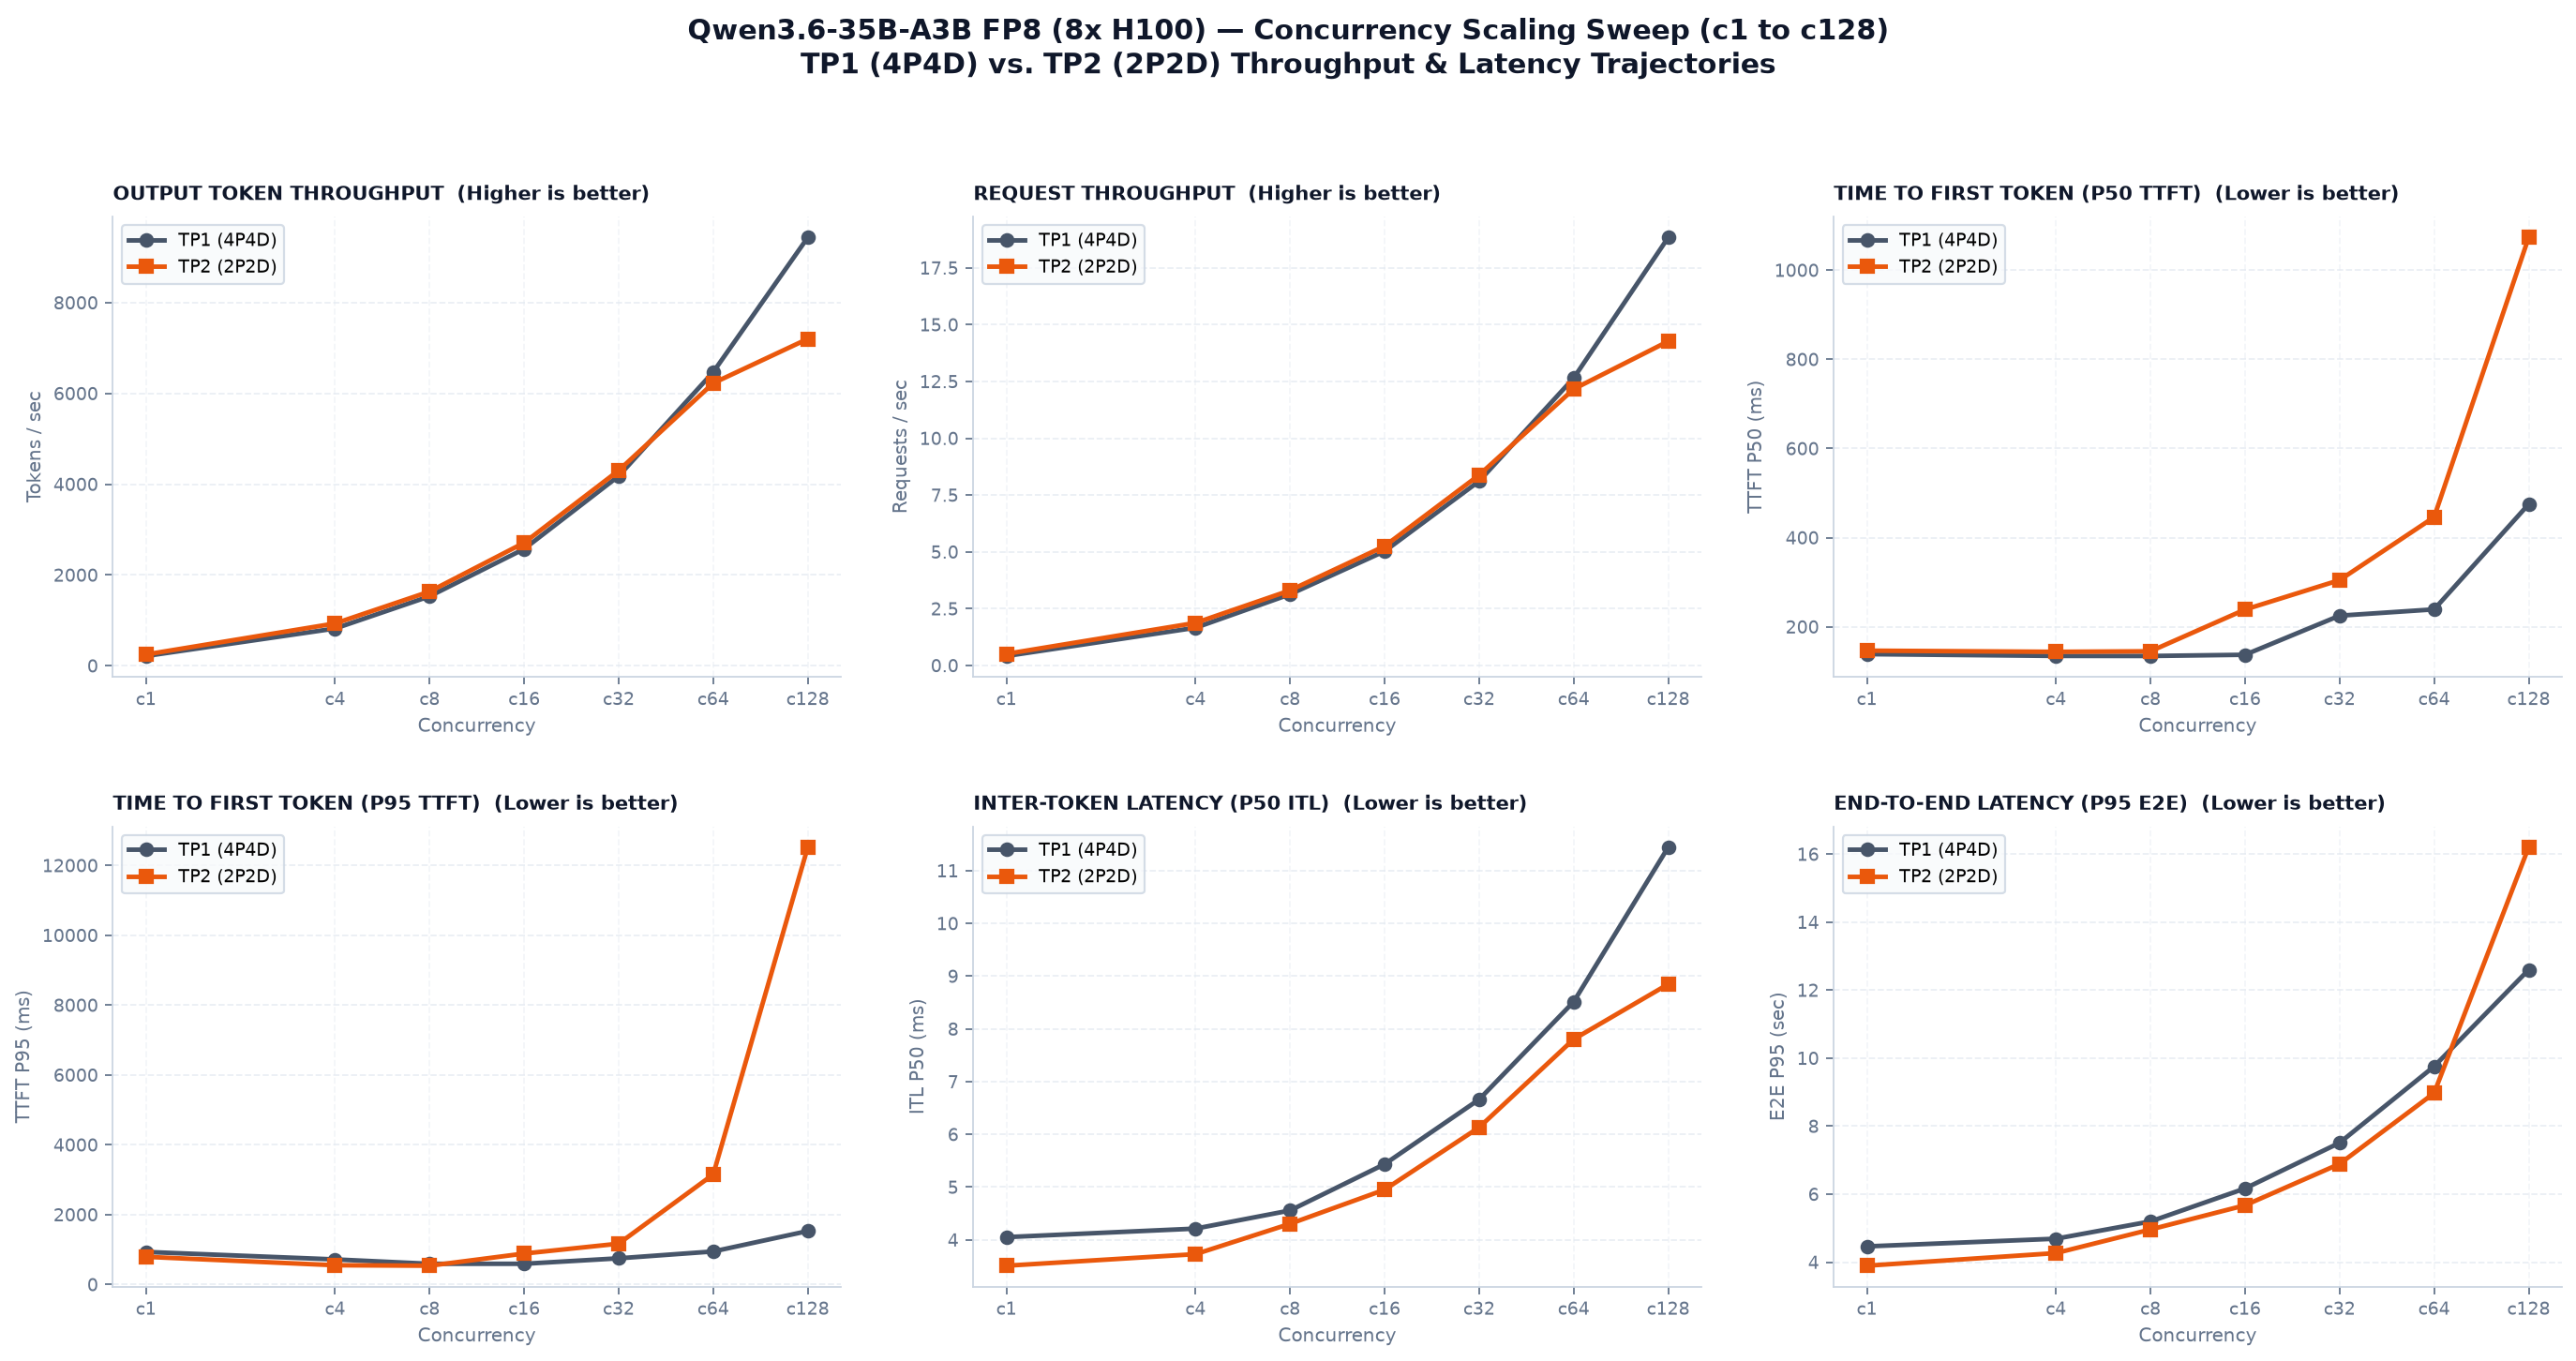

In [21]:
def plot_scaling_curve(ax, title, y_label, tp1_vals, tp2_vals, higher_is_better=True):
    ax.set_facecolor(CARD_BG)
    ax.plot(CONCURRENCIES, tp1_vals, marker="o", markersize=6, linewidth=2.2, color=COLOR_BASELINE, label="TP1 (4P4D)", zorder=4)
    ax.plot(CONCURRENCIES, tp2_vals, marker="s", markersize=6, linewidth=2.2, color=COLOR_OFFLOAD, label="TP2 (2P2D)", zorder=4)
    
    ax.set_xscale("log", base=2)
    ax.set_xticks(CONCURRENCIES)
    ax.set_xticklabels([f"c{c}" for c in CONCURRENCIES], color=TEXT_MAIN, fontsize=8.5)
    ax.set_ylabel(y_label, color=TEXT_MUTED, fontsize=9.0)
    ax.set_xlabel("Concurrency", color=TEXT_MUTED, fontsize=9.0)
    ax.tick_params(axis="both", colors=TEXT_MUTED, labelsize=8.5)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7, color=GRID_COLOR, zorder=1)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4, color=GRID_COLOR, zorder=1)
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(BORDER_COLOR)
        
    dir_str = "Higher is better" if higher_is_better else "Lower is better"
    ax.set_title(f"{title.upper()}  ({dir_str})", loc="left", fontsize=9.5, fontweight="bold", color=TEXT_DARK, pad=8)
    ax.legend(frameon=True, facecolor="#f8fafc", edgecolor="#cbd5e1", fontsize=8.5, loc="best")

fig, axes = plt.subplots(2, 3, figsize=(18, 9.5), facecolor=BG_COLOR, dpi=160)
fig.suptitle(
    "Qwen3.6-35B-A3B FP8 (8x H100) — Concurrency Scaling Sweep (c1 to c128)\nTP1 (4P4D) vs. TP2 (2P2D) Throughput & Latency Trajectories",
    color=TEXT_DARK,
    fontsize=13.5,
    fontweight="bold",
    y=0.98,
)

scaling_metrics = [
    ("Output Token Throughput", "Tokens / sec", [tp1_all[c]["output_tokens_per_sec"] for c in CONCURRENCIES], [tp2_all[c]["output_tokens_per_sec"] for c in CONCURRENCIES], True),
    ("Request Throughput", "Requests / sec", [tp1_all[c]["request_throughput"] for c in CONCURRENCIES], [tp2_all[c]["request_throughput"] for c in CONCURRENCIES], True),
    ("Time to First Token (P50 TTFT)", "TTFT P50 (ms)", [tp1_all[c]["ttft_p50_ms"] for c in CONCURRENCIES], [tp2_all[c]["ttft_p50_ms"] for c in CONCURRENCIES], False),
    ("Time to First Token (P95 TTFT)", "TTFT P95 (ms)", [tp1_all[c]["ttft_p95_ms"] for c in CONCURRENCIES], [tp2_all[c]["ttft_p95_ms"] for c in CONCURRENCIES], False),
    ("Inter-Token Latency (P50 ITL)", "ITL P50 (ms)", [tp1_all[c]["itl_p50_ms"] for c in CONCURRENCIES], [tp2_all[c]["itl_p50_ms"] for c in CONCURRENCIES], False),
    ("End-to-End Latency (P95 E2E)", "E2E P95 (sec)", [tp1_all[c]["e2e_p95_s"] for c in CONCURRENCIES], [tp2_all[c]["e2e_p95_s"] for c in CONCURRENCIES], False),
]

for ax, (t, y_lbl, v1, v2, hib) in zip(axes.flatten(), scaling_metrics):
    plot_scaling_curve(ax, t, y_lbl, v1, v2, higher_is_better=hib)

plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.94], h_pad=2.8, w_pad=2.2)
plt.show()

### 5. Summary Table (c1 to c128)

In [22]:
try:
    import pandas as pd
    rows = []
    for c in CONCURRENCIES:
        d1 = tp1_all.get(c, {})
        d2 = tp2_all.get(c, {})
        t1_out = d1.get("output_tokens_per_sec", 0)
        t2_out = d2.get("output_tokens_per_sec", 0)
        t1_req = d1.get("request_throughput", 0)
        t2_req = d2.get("request_throughput", 0)
        t1_ttft50 = d1.get("ttft_p50_ms", 0)
        t2_ttft50 = d2.get("ttft_p50_ms", 0)
        t1_ttft95 = d1.get("ttft_p95_ms", 0)
        t2_ttft95 = d2.get("ttft_p95_ms", 0)
        t1_itl50 = d1.get("itl_p50_ms", 0)
        t2_itl50 = d2.get("itl_p50_ms", 0)
        
        if c <= 32:
            lead = f"TP2 ITL {t2_itl50:.2f}ms"
        else:
            diff = ((t1_out - t2_out) / t2_out) * 100
            lead = f"TP1 +{diff:.1f}% Out Tok/s"
            
        rows.append({
            "Concurrency": f"c{c}",
            "TP1 Out (tok/s)": f"{t1_out:,.1f}",
            "TP2 Out (tok/s)": f"{t2_out:,.1f}",
            "TP1 Req (req/s)": f"{t1_req:.2f}",
            "TP2 Req (req/s)": f"{t2_req:.2f}",
            "TP1 TTFT P50": f"{t1_ttft50:.1f} ms",
            "TP2 TTFT P50": f"{t2_ttft50:.1f} ms",
            "TP1 TTFT P95": f"{t1_ttft95:.1f} ms",
            "TP2 TTFT P95": f"{t2_ttft95:.1f} ms",
            "TP1 ITL P50": f"{t1_itl50:.2f} ms",
            "TP2 ITL P50": f"{t2_itl50:.2f} ms",
            "Key Advantage": lead,
        })
    
    df = pd.DataFrame(rows)
    display(df)
except ImportError:
    print("Pandas is not installed. Tabular data loaded in dictionary form.")

,Concurrency,TP1 Out (tok/s),TP2 Out (tok/s),TP1 Req (req/s),TP2 Req (req/s),TP1 TTFT P50,TP2 TTFT P50,TP1 TTFT P95,TP2 TTFT P95,TP1 ITL P50,TP2 ITL P50,Key Advantage
0,c1,214.6,247.8,0.42,0.51,138.5 ms,146.4 ms,931.2 ms,791.4 ms,4.05 ms,3.51 ms,TP2 ITL 3.51ms
1,c4,819.6,931.4,1.66,1.87,134.5 ms,143.8 ms,717.1 ms,550.2 ms,4.21 ms,3.73 ms,TP2 ITL 3.73ms
2,c8,"1,529.9","1,634.6",3.13,3.30,134.4 ms,145.0 ms,591.6 ms,536.8 ms,4.56 ms,4.30 ms,TP2 ITL 4.30ms
3,c16,"2,573.5","2,709.5",5.03,5.25,137.1 ms,238.6 ms,591.9 ms,885.0 ms,5.43 ms,4.95 ms,TP2 ITL 4.95ms
4,c32,"4,180.0","4,302.1",8.11,8.38,224.8 ms,304.6 ms,748.7 ms,1168.1 ms,6.66 ms,6.13 ms,TP2 ITL 6.13ms
5,c64,"6,470.5","6,226.0",12.65,12.16,239.0 ms,445.9 ms,944.7 ms,3150.2 ms,8.51 ms,7.80 ms,TP1 +3.9% Out Tok/s
6,c128,"9,435.7","7,201.8",18.83,14.26,474.9 ms,1073.3 ms,1529.3 ms,12520.0 ms,11.44 ms,8.85 ms,TP1 +31.0% Out Tok/s
